## Predicción de los Arrestos en los crímenes de Chigado
Este es el Notebook de Preprocesamiento


Listo al 18/01/25 2:31am

Dataset: Chicago_crimes_2021_2017

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
%matplotlib inline

In [ ]:
# Cargamos el dataset
crimes = pd.read_csv('Chicago_Crimes_2012_to_2017.csv')

print('Dataset listo..')

print('Tamaño del Dataset antes de eliminar duplicados: ', crimes.shape)
crimes.drop_duplicates(subset=['ID', 'Case Number'], inplace=True) #Eliminando dublicados
print('Tamaño del Dataset después de eliminar duplicados: ', crimes.shape)


Dataset listo..
Tamaño del Dataset antes de eliminar duplicados:  (1456714, 23)
Tamaño del Dataset después de eliminar duplicados:  (1456714, 23)


In [ ]:
#Obtener muestra estratificada
proporcion_muestra = 0.02
crimes_new = crimes.groupby('Arrest').apply(lambda x: x.sample(frac=proporcion_muestra)).reset_index(drop=True)

<ipython-input-34-bc229d2a2793>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  crimes_new = crimes.groupby('Arrest').apply(lambda x: x.sample(frac=proporcion_muestra)).reset_index(drop=True)


### Conversion de Tipos

In [ ]:
# Tranformacion de Variables
crimes_new['Date'] = pd.to_datetime(crimes_new['Date'], format='%m/%d/%Y %I:%M:%S %p')

for col in ['ID', 'Case Number', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code']:
    if col in crimes_new.columns:
        try:
          crimes_new[col] = crimes_new[col].astype('category')
        except:
          pass

crimes_new['Year'] = crimes_new['Year'].astype('int')

for col in ['Latitude', 'Longitude', 'X Coordinate']:
    if col in crimes_new.columns:
        crimes_new[col] = pd.to_numeric(crimes_new[col], errors='coerce')

crimes_new = crimes_new.drop('Location', axis = 1, errors= 'ignore')

if 'Updated On' in crimes_new.columns:
    crimes_new['Updated On'] = pd.to_datetime(crimes_new['Updated On'], errors='coerce')

crimes_new.dtypes

,0
Unnamed: 0,int64
ID,category
Case Number,category
Date,datetime64[ns]
Block,category
IUCR,category
Primary Type,category
Description,category
Location Description,category
Arrest,category


### Codificacion de Variables

In [ ]:
# Identificar columnas categóricas
categorical_cols = crimes_new.select_dtypes(include=['category', 'object', 'bool']).columns

label_encoders = {}

# Convertir valores en columnas categóricas a str
for col in categorical_cols:
    crimes_new[col] = crimes_new[col].astype(str)
    le = LabelEncoder()
    crimes_new[col] = le.fit_transform(crimes_new[col])  # Codificar valores categóricos
    label_encoders[col] = le

print(crimes_new.head())
print(crimes_new.dtypes)


   Unnamed: 0     ID  Case Number                Date  Block  IUCR  \
0     2684128  15276         5445 2012-10-23 09:30:00  11218    73   
1      866513  28749        18947 2015-02-20 03:48:00   8063   116   
2     2866130  18879         9046 2013-05-31 00:01:00  12588   206   
3     2879027  19122         9293 2013-06-13 20:30:00   6190    75   
4     6142784   8008        27340 2016-09-13 15:00:00  11004   116   

   Primary Type  Description  Location Description  Arrest  ...  District  \
0            27          162                    90       0  ...        19   
1             6          222                    90       0  ...        10   
2            20          114                    77       0  ...        16   
3            27          107                    80       0  ...         7   
4             6          222                    72       0  ...        13   

   Ward  Community Area  FBI Code  X Coordinate  Y Coordinate  Year  \
0    46              64         7     1172201

In [ ]:
crimes_new.dropna(inplace=True)  #Eliminar datos con valores NAN

In [ ]:
crimes_new['Dates'] = pd.to_datetime(crimes['Date']).dt.date
crimes_new['Time'] = pd.to_datetime(crimes['Date']).dt.time

<ipython-input-38-d987ed864018>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crimes_new['Dates'] = pd.to_datetime(crimes['Date']).dt.date
<ipython-input-38-d987ed864018>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crimes_new['Time'] = pd.to_datetime(crimes['Date']).dt.time


In [ ]:
categorical_cols = crimes_new.select_dtypes(include=['datetime64[ns]', 'object']).columns

In [ ]:
label_encoders = {}  # Dictionary to store LabelEncoders for each column

for col in categorical_cols:
    le = LabelEncoder()
    crimes_new[col] = le.fit_transform(crimes_new[col])

crimes_new.dtypes

,0
Unnamed: 0,int64
ID,int64
Case Number,int64
Date,int64
Block,int64
IUCR,int64
Primary Type,int64
Description,int64
Location Description,int64
Arrest,int64


### Matriz de Correlación

                      Unnamed: 0        ID  Case Number      Date     Block  \
Unnamed: 0              1.000000 -0.386544     0.620467  0.617370 -0.009709   
ID                     -0.386544  1.000000    -0.330875 -0.329903  0.007687   
Case Number             0.620467 -0.330875     1.000000  0.998955 -0.011316   
Date                    0.617370 -0.329903     0.998955  1.000000 -0.011510   
Block                  -0.009709  0.007687    -0.011316 -0.011510  1.000000   
IUCR                   -0.041155  0.030259    -0.021329 -0.022094 -0.005672   
Primary Type           -0.012100  0.027928    -0.007591 -0.009876 -0.084115   
Description            -0.027053  0.008587    -0.025178 -0.022971 -0.014097   
Location Description   -0.003892  0.004013     0.001333  0.002445  0.022861   
Arrest                 -0.065931  0.047685    -0.060577 -0.057356 -0.026054   
Domestic                0.018079 -0.023657     0.022112  0.023091  0.090040   
Beat                   -0.020086  0.015684    -0.016

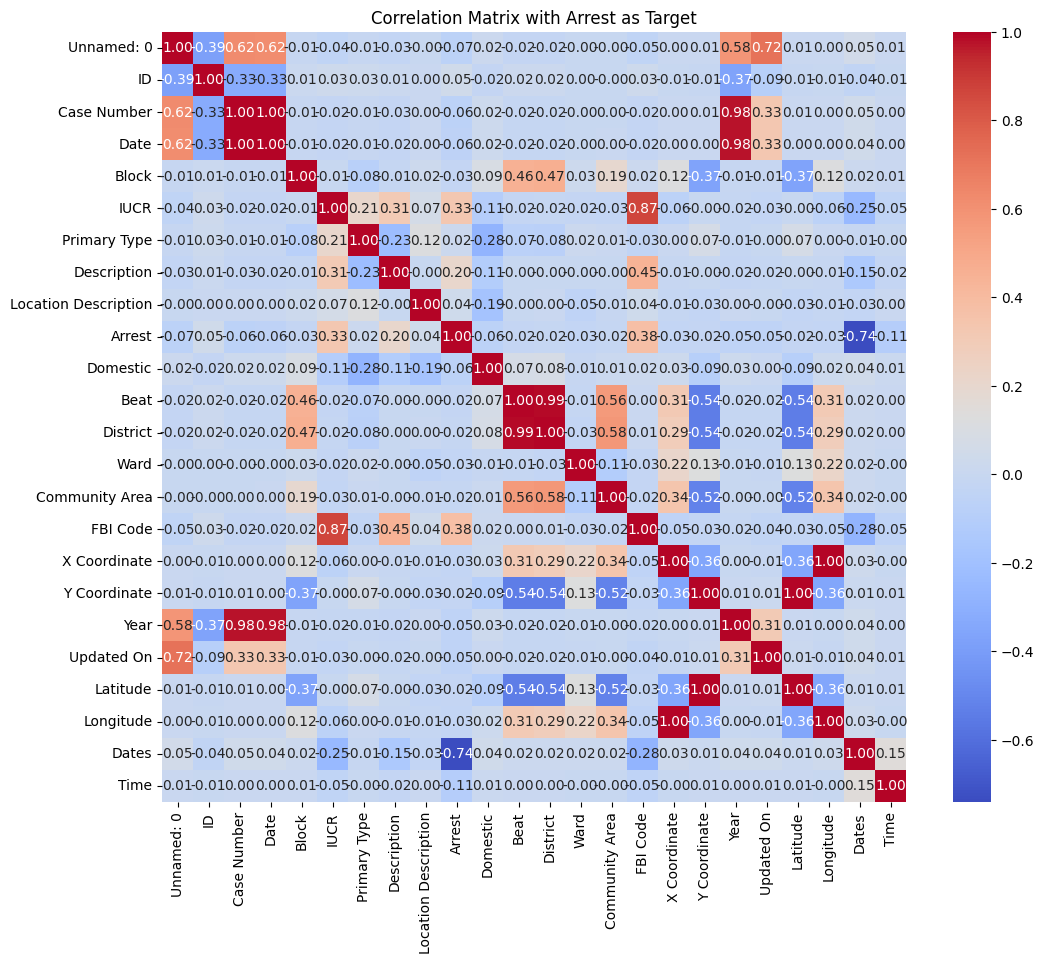

In [ ]:
#Matriz de correlacion de variables
correlation_matrix = crimes_new.corr()

print(correlation_matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix with Arrest as Target')
plt.show()

### Eliminación de instancias
Se eliminan aquellas que están fuera de los límites de chicago

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(crimes_new.isnull(), cbar = False, cmap = 'viridis')

In [ ]:
#Elimina los registros que estan fuera de el area de coordenadas donde se ubica Chicago.
crimes_new.iloc[(crimes_new[['Longitude']].values < -88.0).flatten(), crimes_new.columns=='Longitude'] = 0.0
crimes_new.iloc[(crimes_new[['Longitude']].values > -87.5).flatten(), crimes_new.columns=='Longitude'] = 0.0
crimes_new.iloc[(crimes_new[['Latitude']].values < 41.60).flatten(),  crimes_new.columns=='Latitude'] = 0.0
crimes_new.iloc[(crimes_new[['Latitude']].values > 42.05).flatten(),  crimes_new.columns=='Latitude'] = 0.0
crimes_new.replace({'Latitude': 0.0, 'Longitude': 0.0}, np.nan, inplace=True)
crimes_new.dropna(inplace=True)

### Verificacion del Dataset

In [ ]:
crimes_new.shape

(28418, 24)

In [ ]:
crimes_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28418 entries, 0 to 29133
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            28418 non-null  int64  
 1   ID                    28418 non-null  int64  
 2   Case Number           28418 non-null  int64  
 3   Date                  28418 non-null  int64  
 4   Block                 28418 non-null  int64  
 5   IUCR                  28418 non-null  int64  
 6   Primary Type          28418 non-null  int64  
 7   Description           28418 non-null  int64  
 8   Location Description  28418 non-null  int64  
 9   Arrest                28418 non-null  int64  
 10  Domestic              28418 non-null  int64  
 11  Beat                  28418 non-null  int64  
 12  District              28418 non-null  int64  
 13  Ward                  28418 non-null  int64  
 14  Community Area        28418 non-null  int64  
 15  FBI Code              28

In [ ]:
crimes_new.to_csv("crimenes_estratificado.csv")

### Exporacion y Analisis de Datos para la Clasificación

Distribucion de delitos comentido basados en distritos

In [ ]:
crimes_procesado = pd.read_csv("crimenes_estratificado.csv")

**Mapa de calor de Crímenes por Distrito**

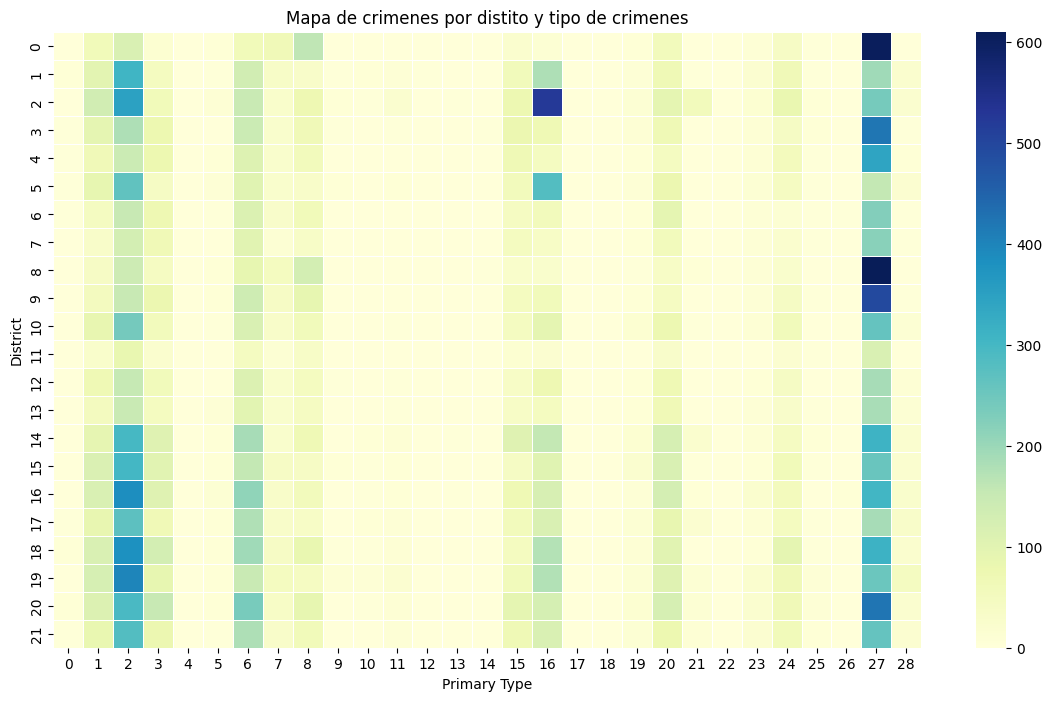

In [ ]:
crimes_DxPT = pd.crosstab(crimes_procesado['District'], crimes_procesado['Primary Type'])

plt.figure(figsize=(14,8))
sns.heatmap(crimes_DxPT, cmap= 'YlGnBu', linewidths=0.5)
plt.title("Mapa de crimenes por distito y tipo de crimenes")
plt.xlabel('Primary Type')
plt.ylabel('District')
plt.show()

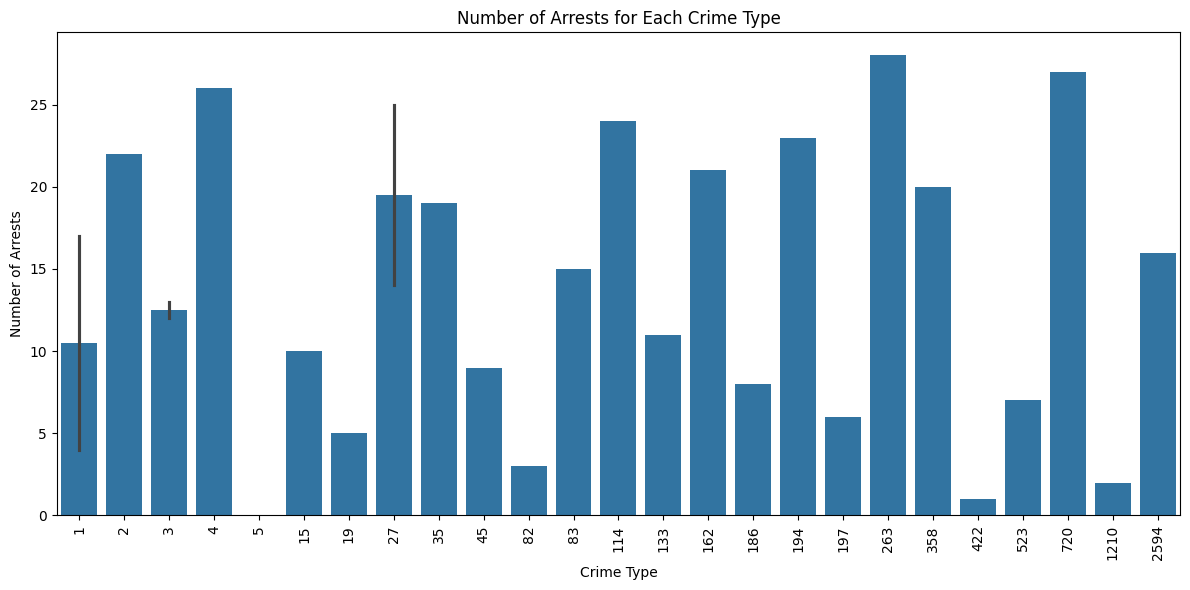

In [ ]:
arrest_counts = crimes_new[crimes_new['Arrest'] == True]['Primary Type'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=arrest_counts.values, y=arrest_counts.index)
plt.xticks(rotation=90)
plt.xlabel("Primary Type")
plt.ylabel("Numero de Arrestos")
plt.title("Numero de arrestos por tipo de crimen")
plt.tight_layout()
plt.show()

In [ ]:
crimes_procesado['Date'] = pd.to_datetime(crimes_procesado['Date'], errors='coerce')
crimes_procesado['Updated On'] = pd.to_datetime(crimes_procesado['Updated On'], errors='coerce')

missing_values = crimes_procesado.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
crimes_procesado['Hour'] = crimes_procesado['Date'].dt.hour
crimes_procesado['Month'] = crimes_procesado['Date'].dt.month

Dado que nuestra variable objetivo [Arrest] no tiene correlación fuerte con ninguna variable, se seleccionan las variables más representativas en el contexto del problema a tratar

In [ ]:
crimes_new.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Dates,Time
0,2684128,15276,5445,5117,11218,73,27,162,90,0,...,64,7,1172201.0,1857577.0,2012,187,41.764636,-87.644396,1294,1515
1,866513,28749,18947,17770,8063,116,6,222,90,0,...,31,16,1177918.0,1874955.0,2015,0,41.812196,-87.622915,1294,1390
2,2866130,18879,9046,8550,12588,206,20,114,77,0,...,42,25,1189743.0,1846051.0,2013,187,41.732604,-87.580470,1294,1506
3,2879027,19122,9293,8765,6190,75,27,107,80,0,...,13,7,1156144.0,1921425.0,2013,187,41.940180,-87.701528,1294,1423
4,6142784,8008,27340,25398,11004,116,6,222,72,0,...,0,16,1165106.0,1946334.0,2016,542,42.008345,-87.667878,1294,1411


In [ ]:
# Seleccion de características y Variable Objetivo
features = ['Primary Type','Beat', 'District', 'Ward','Community Area','Year', 'Hour', 'Month','Latitude','Longitude']
X = crimes_procesado[features]
y = crimes_procesado['Arrest']

<ipython-input-54-bacb8a6e3828>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


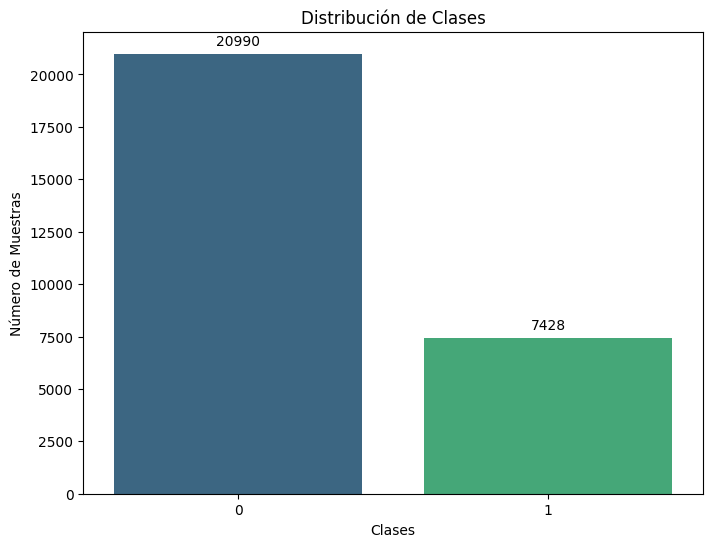

In [ ]:
# Función para graficar la distribución de las clases
def plot_class_distribution(y):
    class_counts = pd.Series(y).value_counts()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title("Distribución de Clases")
    plt.xlabel("Clases")
    plt.ylabel("Número de Muestras")
    for i, count in enumerate(class_counts.values):
        plt.text(i, count + 0.02 * max(class_counts.values), str(count), ha='center')
    plt.show()

# Graficar distribución de clases en el conjunto de datos original
plot_class_distribution(y)

**Submuestreo**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_test, y_train, y_test

(       Primary Type  Beat  District  Ward  Community Area  Year  Hour  Month  \
 3376             27    77         5    21              17  2013     0      1   
 25446            16    10         1     3              23  2013     0      1   
 2851             27    56         3    19              16  2012     0      1   
 8631             27   257        19     6              63  2013     0      1   
 11860             2   140        11    42              74  2016     0      1   
 ...             ...   ...       ...   ...             ...   ...   ...    ...   
 12151            19    31         0    36              20  2013     0      1   
 1430              6   264        19     8              63  2015     0      1   
 22740            16   234        17    46              43  2014     0      1   
 2394              1    56         3    19              16  2012     0      1   
 15614             3    19         2    18              15  2015     0      1   
 
         Latitude  Longitu

In [ ]:
X_train.shape

(19892, 10)

In [ ]:
y_train.shape

(19892,)

In [ ]:
X_test.shape

(8526, 10)

In [ ]:
y_test.shape

(8526,)

In [ ]:
# Guardar los datos separado en archivos CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)